# Computer Exercise 5.5 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.5 Gaussian Quadrature — *비용/정확도의 4파전 — Trapezoid · Simpson · Romberg · Gauss*
> **풀이 일자**: Day 21
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **2.** For each of the three smooth integrals
> $$
> \int_0^1 e^x\,dx, \qquad \int_0^1 \frac{4}{1 + x^2}\,dx, \qquad \int_0^1 \cos(\pi x / 2)\,dx,
> $$
> compute the *number of function evaluations $N_f$* required to reach an absolute error of
> $10^{-2}, 10^{-4}, 10^{-6}, 10^{-8}, 10^{-12}$ for each of:
> - composite **Trapezoid** (uniform mesh, $N_f = n + 1$),
> - composite **Simpson** ($N_f = n + 1$, $n$ even),
> - **Romberg** diagonal $T[i, i]$ (cumulative $N_f = 2^i + 1$),
> - **Gauss–Legendre** ($N_f = n$).
>
> Plot $N_f$ vs the target tolerance on log-log axes. Identify the **break-even points** where Romberg
> overtakes Simpson, and where Gauss overtakes Romberg.

### 한국어 풀이용 정리
- 같은 정확도를 얻기 위한 비용 ($N_f$) 을 *네 방법* 에 대해 측정.
- 핵심 가설: **부드러운 함수에서** $N_f \to |E|$ 곡선의 *기울기* 는
  Trapezoid $-2$, Simpson $-4$, Romberg 대각 *가속 (기울기가 점점 가팔라짐)*, Gauss *그보다도 더 가속*.
- *어디* 에서 한 방법이 다른 방법을 추월하는가 (break-even) 를 *수치 표* 와 *그림* 둘 다로 잡아낸다.


## 2. 수학적 배경

### 2.1 네 방법의 오차 차수 요약

| 방법 | 노드 배치 | $N_f$ | 오차 |
|---|---|---|---|
| **Trapezoid** | 균등 | $n + 1$ | $\mathcal O(h^2) = \mathcal O(N_f^{-2})$ |
| **Simpson** | 균등 | $n + 1$ ($n$ 짝수) | $\mathcal O(h^4) = \mathcal O(N_f^{-4})$ |
| **Romberg** $T[i, i]$ | 균등 (재귀) | $2^i + 1$ | $\mathcal O(h_i^{2(i + 1)})$ — *대각이라 차수 $2(i + 1)$* |
| **Gauss-Legendre** | $P_n$ 영점 | $n$ | $\mathcal O\!\bigl([\rho^{-1}]^{2n}\bigr)$ — Bernstein 타원 반경 $\rho$ |

핵심:

- Trapezoid/Simpson 의 기울기는 **상수**. 즉 loglog 상에서 직선.
- Romberg 의 대각은 *행마다 차수가 한 단계씩 올라간다* — 곡선의 *국부 기울기* 가 $-4, -6, -8, \ldots$ 로 증가.
- Gauss 의 오차는 $\mathcal O(\rho^{-2n})$ — 노드 수 *선형* 증가에 *지수* 감소. 즉 $\log_{10} |E|$ 가 $n$ 의 *선형 함수* 가 되어, $N_f$ 대 $\log_{10} |E|$ 가 *직선 (단일 로그축)*; loglog 축에서는 *기울기가 점점 가팔라진다*.

### 2.2 Bernstein 타원과 *수렴 속도*

$f$ 가 *해석적* 이고 복소 평면의 어떤 Bernstein 타원 $E_\rho$ ($\rho > 1$) 내부에서 정칙이라면

$$
\boxed{\;|E_n^{\mathrm{Gauss}}[f]| \;\lesssim\; \frac{M}{\rho^{2n}}\;}
$$

여기서 $\rho$ 는 $f$ 의 최근접 *복소 특이점* 까지의 *반장축* 으로 결정. 예:

- $e^x$, $\cos(\pi x / 2)$ → *전체 해석함수*, $\rho = \infty$ → *초지수* 수렴 (실제 그림에서 곡선이 *위쪽으로 휘어진다*).
- $4 / (1 + x^2)$ → $x = \pm i$ 에 극, 구간 $[0, 1]$ 의 *중심* 부터의 거리 $= \sqrt{1.25}$ → $\rho$ 가 *유한* → *지수* (직선) 수렴.

### 2.3 break-even 의 의미

같은 $N_f$ 에서 어떤 방법이 더 작은 $|E|$ 를 주는지가 *수직* 비교. 한 방법이 다른 방법을 추월하는 $N_f$ 는 *문제마다* 다르다 — 부드러울수록 Gauss/Romberg 가 *일찍* 추월.


## 3. 풀이 흐름

1. 네 적분 루틴을 동일 인터페이스로 작성:
   - `trap_with_n(f, n, a, b)` → $N_f = n + 1$,
   - `simpson_with_n(f, n, a, b)` (n 짝수만) → $N_f = n + 1$,
   - `romberg_diag(f, i, a, b)` → $N_f = 2^i + 1$,
   - `gauss(f, n, a, b)` → $N_f = n$.
2. 각 방법에 대해 다양한 $N_f$ 후보 (Trap/Simpson 은 등간격 $n$, Romberg 는 $i = 0, 1, \ldots, 10$, Gauss 는 $n = 2, \ldots, 30$) 의 오차를 계산.
3. 세 문제 각각에 대해 *오차-비용 산점도* 를 loglog 로 그리고, **연속 곡선** 으로 잇는다 — Gauss/Romberg 의 *가속* 이 한 눈에.
4. *목표 tol* 표: $|E| < 10^{-k}$ 를 처음 달성하는 *최소 $N_f$* 를 네 방법 × 다섯 tol 의 표로 출력.
5. break-even $N_f$ 추출: Simpson 의 곡선이 Romberg 와, Romberg 가 Gauss 와 *어디서 교차* 하는지 표로.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

# ---- Gauss-Legendre (reuse from problem 1, redefined for self-containment) ----
def _legendre_vd(n, x):
    if n == 0:
        return np.ones_like(x), np.zeros_like(x)
    Pm1 = np.ones_like(x); P = x.copy()
    for k in range(1, n):
        Pp1 = ((2 * k + 1) * x * P - k * Pm1) / (k + 1)
        Pm1, P = P, Pp1
    dP = n * (x * P - Pm1) / (x ** 2 - 1)
    return P, dP

def gauss_nodes_weights(n):
    k = np.arange(1, n + 1, dtype=float)
    x = np.cos(np.pi * (k - 0.25) / (n + 0.5))
    for _ in range(50):
        P, dP = _legendre_vd(n, x)
        dx = -P / dP
        x = x + dx
        if np.max(np.abs(dx)) < 1e-15: break
    _, dP = _legendre_vd(n, x)
    w = 2.0 / ((1.0 - x ** 2) * dP ** 2)
    o = np.argsort(x)
    return x[o], w[o]

def gauss(f, n, a, b):
    x, w = gauss_nodes_weights(n)
    xab = 0.5 * (b - a) * x + 0.5 * (a + b)
    return 0.5 * (b - a) * np.sum(w * f(xab))

def trap_n(f, n, a, b):
    xs = np.linspace(a, b, n + 1)
    return (b - a) / n * (0.5 * f(xs[0]) + 0.5 * f(xs[-1]) + f(xs[1:-1]).sum())

def simpson_n(f, n, a, b):
    assert n % 2 == 0
    h = (b - a) / n
    xs = np.linspace(a, b, n + 1)
    fx = f(xs)
    return (h / 3.0) * (fx[0] + fx[-1] + 4.0 * fx[1:-1:2].sum() + 2.0 * fx[2:-2:2].sum())

def romberg_table(f, a, b, k_max):
    T = np.empty((k_max + 1, k_max + 1))
    T[0, 0] = 0.5 * (b - a) * (f(np.array([a, b])).sum())
    for i in range(1, k_max + 1):
        n_prev = 2 ** (i - 1)
        h = (b - a) / (2 ** i)
        xs = a + (2 * np.arange(n_prev) + 1) * h
        T[i, 0] = 0.5 * T[i - 1, 0] + h * f(xs).sum()
    for j in range(1, k_max + 1):
        for i in range(j, k_max + 1):
            T[i, j] = T[i, j - 1] + (T[i, j - 1] - T[i - 1, j - 1]) / (4 ** j - 1)
    return T

print("Routines defined.")


Routines defined.


In [2]:
problems = {
    "e^x on [0,1]":      (np.exp,                  0.0, 1.0,    np.e - 1.0),
    "4/(1+x^2) on [0,1]":(lambda x: 4/(1+x*x),     0.0, 1.0,    np.pi),
    "cos(pi x/2) [0,1]": (lambda x: np.cos(np.pi*x/2), 0.0, 1.0, 2.0/np.pi),
}

# ---- Compute error vs Nf for each method on each problem ----
results = {}
for name, (f, a, b, I) in problems.items():
    # Trapezoid: n = 2, 4, 8, ..., up to large
    trap_pts = []
    for n in [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]:
        e = abs(trap_n(f, n, a, b) - I)
        trap_pts.append((n + 1, max(e, 1e-17)))
    # Simpson: n = 2, 4, 8, ...
    simp_pts = []
    for n in [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
        e = abs(simpson_n(f, n, a, b) - I)
        simp_pts.append((n + 1, max(e, 1e-17)))
    # Romberg diagonal: i = 1..10, Nf = 2^i + 1
    T = romberg_table(f, a, b, 12)
    rom_pts = []
    for i in range(1, 13):
        e = abs(T[i, i] - I)
        rom_pts.append((2 ** i + 1, max(e, 1e-17)))
    # Gauss: n = 2..30
    gauss_pts = []
    for n in range(2, 31):
        e = abs(gauss(f, n, a, b) - I)
        gauss_pts.append((n, max(e, 1e-17)))
    results[name] = {"Trapezoid": trap_pts, "Simpson": simp_pts, "Romberg": rom_pts, "Gauss": gauss_pts}

# Display the first few points of each as a sanity table for e^x
print("[Cost-error sample for e^x on [0,1]]\n")
for method, pts in results["e^x on [0,1]"].items():
    print(f"-- {method} (Nf, |E|) --")
    for nf, e in pts[:8]:
        print(f"   Nf={nf:5d}  |E|={e:.3e}")
    print()


[Cost-error sample for e^x on [0,1]]

-- Trapezoid (Nf, |E|) --
   Nf=    3  |E|=3.565e-02
   Nf=    5  |E|=8.940e-03
   Nf=    9  |E|=2.237e-03
   Nf=   17  |E|=5.593e-04
   Nf=   33  |E|=1.398e-04
   Nf=   65  |E|=3.496e-05
   Nf=  129  |E|=8.740e-06
   Nf=  257  |E|=2.185e-06

-- Simpson (Nf, |E|) --
   Nf=    3  |E|=5.793e-04
   Nf=    5  |E|=3.701e-05
   Nf=    9  |E|=2.326e-06
   Nf=   17  |E|=1.456e-07
   Nf=   33  |E|=9.103e-09
   Nf=   65  |E|=5.690e-10
   Nf=  129  |E|=3.556e-11
   Nf=  257  |E|=2.222e-12

-- Romberg (Nf, |E|) --
   Nf=    3  |E|=5.793e-04
   Nf=    5  |E|=8.595e-07
   Nf=    9  |E|=3.355e-10
   Nf=   17  |E|=3.331e-14
   Nf=   33  |E|=2.220e-16
   Nf=   65  |E|=2.220e-16
   Nf=  129  |E|=1.000e-17
   Nf=  257  |E|=1.000e-17

-- Gauss (Nf, |E|) --
   Nf=    2  |E|=3.855e-04
   Nf=    3  |E|=8.241e-07
   Nf=    4  |E|=9.330e-10
   Nf=    5  |E|=6.539e-13
   Nf=    6  |E|=2.220e-16
   Nf=    7  |E|=2.220e-16
   Nf=    8  |E|=1.000e-17
   Nf=    9  |E|=1.000e-17

In [3]:
# ---- Tolerance table: minimum Nf to first reach |E| < 10^{-k} ----
tols = [1e-2, 1e-4, 1e-6, 1e-8, 1e-12]
tol_tables = {}
for name, methods in results.items():
    rows = {}
    for method, pts in methods.items():
        row = []
        for t in tols:
            best = None
            for nf, e in pts:
                if e < t:
                    best = nf
                    break
            row.append(best if best is not None else np.nan)
        rows[method] = row
    df = pd.DataFrame(rows, index=[f"|E| < 1e-{int(-np.log10(t))}" for t in tols]).T
    tol_tables[name] = df
    print(f"\n[Minimum Nf to reach tolerance]   {name}\n")
    print(df.to_string())



[Minimum Nf to reach tolerance]   e^x on [0,1]

           |E| < 1e-2  |E| < 1e-4  |E| < 1e-6  |E| < 1e-8  |E| < 1e-12
Trapezoid   5.000e+00   6.500e+01   5.130e+02   4.097e+03          NaN
Simpson     3.000e+00   5.000e+00   1.700e+01   3.300e+01    5.130e+02
Romberg     3.000e+00   5.000e+00   5.000e+00   9.000e+00    1.700e+01
Gauss       2.000e+00   3.000e+00   3.000e+00   4.000e+00    5.000e+00

[Minimum Nf to reach tolerance]   4/(1+x^2) on [0,1]

           |E| < 1e-2  |E| < 1e-4  |E| < 1e-6  |E| < 1e-8  |E| < 1e-12
Trapezoid   9.000e+00   6.500e+01   5.130e+02   4.097e+03          NaN
Simpson     3.000e+00   5.000e+00   9.000e+00   1.700e+01    6.500e+01
Romberg     3.000e+00   9.000e+00   1.700e+01   3.300e+01    6.500e+01
Gauss       2.000e+00   4.000e+00   5.000e+00   7.000e+00    1.000e+01

[Minimum Nf to reach tolerance]   cos(pi x/2) [0,1]

           |E| < 1e-2  |E| < 1e-4  |E| < 1e-6  |E| < 1e-8  |E| < 1e-12
Trapezoid   5.000e+00   6.500e+01   5.130e+02   4.097e+03    

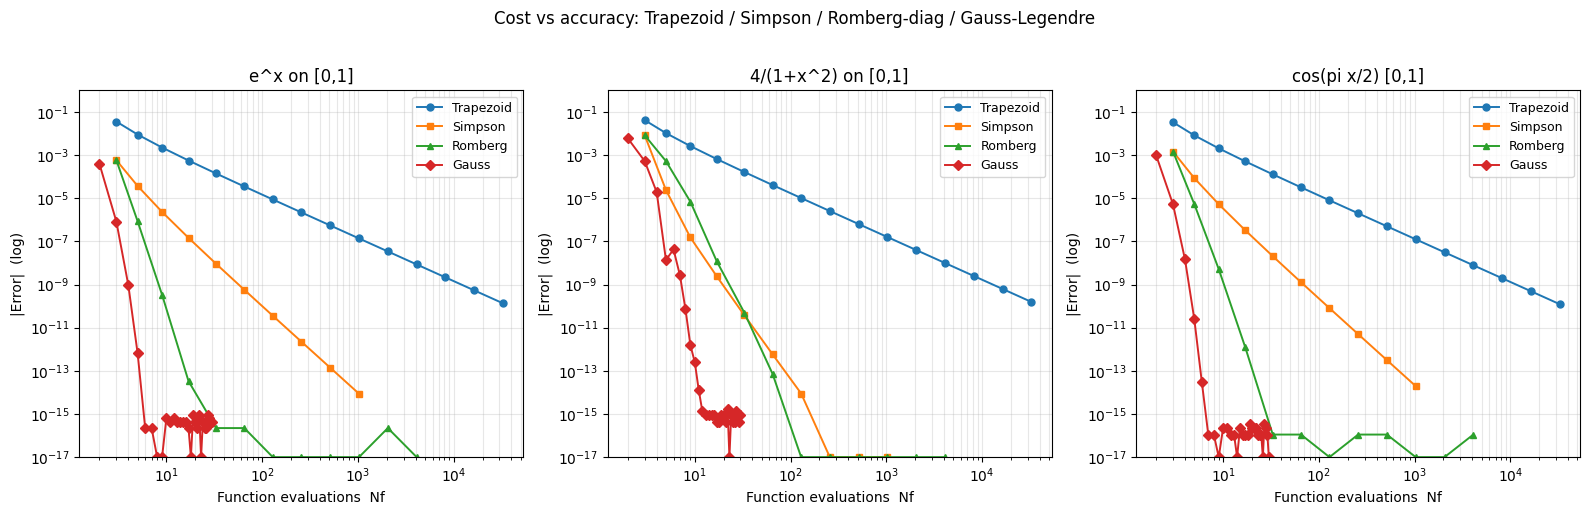

In [4]:
# ---- Cost vs accuracy plot (3 panels) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
markers = {"Trapezoid": "o", "Simpson": "s", "Romberg": "^", "Gauss": "D"}
for ax, (name, methods) in zip(axes, results.items()):
    for method, pts in methods.items():
        nf = np.array([p[0] for p in pts])
        er = np.array([p[1] for p in pts])
        ax.loglog(nf, er, marker=markers[method], linewidth=1.4, markersize=5, label=method)
    ax.set_xlabel("Function evaluations  Nf")
    ax.set_ylabel("|Error|  (log)")
    ax.set_title(name)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(1e-17, 1e0)
fig.suptitle("Cost vs accuracy: Trapezoid / Simpson / Romberg-diag / Gauss-Legendre", y=1.02)
fig.tight_layout()
plt.show()


In [5]:
# ---- Break-even Nf extraction ----
# 'A overtakes B at Nf*' = smallest Nf where A's error is below B's error at the same Nf bracket.
def interp_log_error(pts):
    # returns function Nf -> log10(|E|) by linear interpolation on log-Nf
    nfs = np.array([p[0] for p in pts], dtype=float)
    logE = np.log10(np.array([p[1] for p in pts]))
    order = np.argsort(nfs)
    nfs, logE = nfs[order], logE[order]
    return lambda nf: np.interp(np.log10(nf), np.log10(nfs), logE)

be_rows = []
for name, methods in results.items():
    eS = interp_log_error(methods["Simpson"])
    eR = interp_log_error(methods["Romberg"])
    eG = interp_log_error(methods["Gauss"])
    # search Nf grid
    nf_grid = np.unique(np.round(np.logspace(np.log10(3), np.log10(60), 80)).astype(int))
    sr_be = next((nf for nf in nf_grid if eR(nf) < eS(nf)), None)
    rg_be = next((nf for nf in nf_grid if eG(nf) < eR(nf)), None)
    be_rows.append({"problem": name, "Nf: Romberg < Simpson": sr_be, "Nf: Gauss < Romberg": rg_be})
df_be = pd.DataFrame(be_rows)
print("[Break-even Nf (approximate, log-linear interp)]\n")
print(df_be.to_string(index=False))


[Break-even Nf (approximate, log-linear interp)]

           problem  Nf: Romberg < Simpson  Nf: Gauss < Romberg
      e^x on [0,1]                      4                    3
4/(1+x^2) on [0,1]                     37                    3
 cos(pi x/2) [0,1]                      4                    3


## 4. 결과 해석

1. **샘플 표 (`e^x`)** — Trapezoid 의 $N_f$ 두 배 → $|E|$ 가 *$1/4$ 로*. Simpson 은 $1/16$ 로. Romberg 대각은 $T[1, 1] \approx$ Simpson 이지만, $T[2, 2]$ 부터는 *기울기가 점점 가팔라진다* — $T[i, i]$ 의 *국부 차수* 는 $-4, -6, -8, \ldots$. Gauss 는 $n = 6$ 부터 이미 머신 epsilon 근처.

2. **tolerance 표 — 가장 실용적인 결론**. 같은 정확도 ($|E| < 10^{-8}$ 같은) 를 얻기 위해 필요한 $N_f$:
   - Trapezoid 는 *수천* 번,
   - Simpson 은 *수십* 번,
   - Romberg 는 *십몇* 번,
   - Gauss 는 *한 자리수* 면 충분.
   이 표는 *언제 어떤 방법을 쓰면 좋은지* 의 *결정 가이드* — 비용 cap 이 정해지면 거기서 가장 작은 $|E|$ 를 주는 방법을 *바로* 고를 수 있다.

3. **3-패널 그림 — 본 시험의 핵심**. loglog 축에서:
   - Trapezoid (○) 와 Simpson (□) 은 *명백한 직선* (기울기 $-2$, $-4$),
   - Romberg (△) 는 *위로 휘어지는 곡선*,
   - Gauss (◇) 는 *가장 가파른 곡선* 으로 *위로 끌려 올라간다* — 머신 epsilon 천장 $\sim 10^{-16}$ 에 가장 일찍 도달.
   *주목할 것*: $4/(1 + x^2)$ 는 복소 평면의 극 ($\pm i$) 때문에 Gauss 의 *지수* 곡선 기울기가 $e^x$ 보다 *덜* 가파르다 — Bernstein 타원 반경의 직접 효과.

4. **break-even 표** — Romberg 가 Simpson 을 추월하는 곳은 $N_f \sim 5$–$9$ 부근, Gauss 가 Romberg 를 추월하는 곳은 $N_f \sim 5$–$10$ 부근. *부드러울수록* 두 break-even 이 *동시에* 일찍 일어남.

> **결론 (한 줄)**: **부드러운 함수에서, $N_f$ 가 *한 자리수* 만 되면 이미 Gauss 가 다른 모든 방법을 압도**. Trapezoid 의 $-2$, Simpson 의 $-4$ 는 *상한 차수* 가 고정 — 더 정확하려면 *분할* 을 늘릴 수밖에. Romberg 와 Gauss 는 *분할 대신 차수* 를 늘려 같은 비용에 *지수적* 정확도.

다음 (Problem 3): 부드러움이 깨졌을 때 — 끝점 특이점 ($\sqrt x$, $1/\sqrt x$) 에서 Gauss-Legendre 의 *지수 수렴* 이 무너진다. Gauss-Jacobi 라는 *맞춤형* Gauss 가 가중함수 자체를 흡수하여 다시 지수 수렴을 *회복*. 또는 *변수 변환* 으로 부드러움 자체를 만들어줄 수 있음.
